In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages



In [3]:
## annotated -> help us to annot the message like its human message or its ai message to each message
class State(TypedDict):
    messages:Annotated[list,add_messages]


In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [ ]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_5f78e76dfa', 'id': 'chatcmpl-DaEV3GKh8EooqSUT0nsYRen12yCak', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ddceb-84c2-7f80-8ff9-9ca71d652551-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [10]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="llama-3.1-8b-instant")
llm_groq.invoke("hey")

AIMessage(content="How's it going? Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 36, 'total_tokens': 57, 'completion_time': 0.022137464, 'completion_tokens_details': None, 'prompt_time': 0.001846981, 'prompt_tokens_details': None, 'queue_time': 0.050856139, 'total_time': 0.023984445}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ddcef-35a8-71a3-ad23-54f836a07fdb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 21, 'total_tokens': 57})

In [11]:
def scofield(state:State):
    return {"messages": [llm_groq.invoke(state['messages'])]}

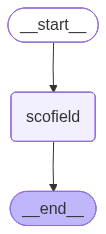

In [12]:
graph=StateGraph(State)

graph.add_node("scofield", scofield)

graph.add_edge(START, "scofield")
graph.add_edge("scofield",END)

graph_builder = graph.compile()

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [13]:
## invocation

graph_builder.invoke({'messages': "is learning frontend still relevant? entry level things can easily done by LLM"})

{'messages': [HumanMessage(content='is learning frontend still relevant? entry level things can easily done by LLM', additional_kwargs={}, response_metadata={}, id='68d9b891-5229-4798-8101-6f25ee272214'),
  AIMessage(content="While Large Language Models (LLMs) have made significant advancements in recent years, learning frontend development is still highly relevant and valuable. Here's why:\n\n1. **Creativity and Customization**: LLMs can automate repetitive and simple tasks, but they often struggle with creativity and customization. Frontend developers need to understand the nuances of design, user experience, and behavior, which require human intuition and creativity. They can work with LLMs to generate ideas, but then they need to refine and tailor the output to meet specific requirements.\n2. **Problem-Solving and Critical Thinking**: Frontend development involves solving complex problems, debugging, and troubleshooting. While LLMs can help with code suggestions and error messages,

## Streaming the responses

In [15]:
for event in graph_builder.stream({"messages":"hello my name is raj"}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='hello my name is raj', additional_kwargs={}, response_metadata={}, id='e9489a93-9223-4eae-94a7-f1df077cbe93')]}
{'messages': [HumanMessage(content='hello my name is raj', additional_kwargs={}, response_metadata={}, id='e9489a93-9223-4eae-94a7-f1df077cbe93'), AIMessage(content="Hello Raj, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 40, 'total_tokens': 66, 'completion_time': 0.023462133, 'completion_tokens_details': None, 'prompt_time': 0.001789462, 'prompt_tokens_details': None, 'queue_time': 0.054007583, 'total_time': 0.025251595}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ddd2a-6524-78f2-afb0-e4b969f221bc-0', tool_calls=[], invalid_tool_calls=[], usage_metadat